In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()  # upload healthcare_dataset.csv when prompted

Saving healthcare_dataset.csv to healthcare_dataset (1).csv


In [2]:
df = pd.read_csv('healthcare_dataset.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Load into SQLite in-memory DB
conn = sqlite3.connect(':memory:')
df.to_sql('healthcare', conn, index=False, if_exists='replace')

print("Rows loaded:", len(df))
print(df.columns.tolist())

Rows loaded: 55500
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


In [3]:
queries = {
    "1. Gender Distribution": """
        SELECT Gender, COUNT(*) AS total_patients
        FROM healthcare GROUP BY Gender
    """,
    "2. Common Conditions": """
        SELECT `Medical Condition`, COUNT(*) AS total_cases
        FROM healthcare GROUP BY `Medical Condition`
        ORDER BY total_cases DESC
    """,
    "3. Avg Billing by Condition": """
        SELECT `Medical Condition`, ROUND(AVG(`Billing Amount`),2) AS avg_billing
        FROM healthcare GROUP BY `Medical Condition`
        ORDER BY avg_billing DESC
    """,
    "4. Avg Stay by Condition": """
        SELECT `Medical Condition`,
               ROUND(AVG(JULIANDAY(`Discharge Date`) - JULIANDAY(`Date of Admission`)),1) AS avg_stay_days
        FROM healthcare GROUP BY `Medical Condition`
        ORDER BY avg_stay_days DESC
    """,
    "5. Admission Type Breakdown": """
        SELECT `Admission Type`, COUNT(*) AS total,
               ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM healthcare), 2) AS percentage
        FROM healthcare GROUP BY `Admission Type`
    """,
    "6. Top 5 Hospitals": """
        SELECT Hospital, COUNT(*) AS patients
        FROM healthcare GROUP BY Hospital
        ORDER BY patients DESC LIMIT 5
    """,
    "7. Insurance Revenue": """
        SELECT `Insurance Provider`,
               ROUND(SUM(`Billing Amount`),2) AS total_revenue,
               ROUND(AVG(`Billing Amount`),2) AS avg_billing
        FROM healthcare GROUP BY `Insurance Provider`
        ORDER BY total_revenue DESC
    """,
    "8. Test Results Distribution": """
        SELECT `Test Results`, COUNT(*) AS count,
               ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM healthcare), 2) AS percentage
        FROM healthcare GROUP BY `Test Results`
    """,
    "9. Age Group Segmentation": """
        SELECT
          CASE
            WHEN Age < 18 THEN 'Minor'
            WHEN Age BETWEEN 18 AND 35 THEN 'Young Adult'
            WHEN Age BETWEEN 36 AND 55 THEN 'Middle Age'
            WHEN Age BETWEEN 56 AND 70 THEN 'Senior'
            ELSE 'Elderly'
          END AS age_group,
          COUNT(*) AS total,
          ROUND(AVG(`Billing Amount`),2) AS avg_billing
        FROM healthcare GROUP BY age_group ORDER BY avg_billing DESC
    """,
    "10. Medication Prescriptions": """
        SELECT Medication, COUNT(*) AS prescriptions
        FROM healthcare GROUP BY Medication
        ORDER BY prescriptions DESC
    """,
    "11. Abnormal Results by Condition": """
        SELECT `Medical Condition`, COUNT(*) AS abnormal_cases
        FROM healthcare WHERE `Test Results` = 'Abnormal'
        GROUP BY `Medical Condition` ORDER BY abnormal_cases DESC
    """,
    "12. Top 10 Doctor Load": """
        SELECT Doctor, COUNT(*) AS total_patients,
               ROUND(AVG(`Billing Amount`),2) AS avg_billing
        FROM healthcare GROUP BY Doctor
        ORDER BY total_patients DESC LIMIT 10
    """,
    "13. Blood Type Distribution": """
        SELECT `Blood Type`, COUNT(*) AS count
        FROM healthcare GROUP BY `Blood Type` ORDER BY count DESC
    """,
    "14. High Billing Patients (Top 100)": """
        SELECT Name, `Medical Condition`,
               ROUND(`Billing Amount`,2) AS billing
        FROM healthcare ORDER BY `Billing Amount` DESC LIMIT 100
    """,
    "15. Rank Conditions by Avg Billing": """
        SELECT `Medical Condition`,
               ROUND(AVG(`Billing Amount`),2) AS avg_billing,
               RANK() OVER (ORDER BY AVG(`Billing Amount`) DESC) AS billing_rank
        FROM healthcare GROUP BY `Medical Condition`
    """
}

for title, query in queries.items():
    print(f"\n{'='*50}")
    print(f"{title}")
    print('='*50)
    result = pd.read_sql_query(query, conn)
    print(result.to_string(index=False))


1. Gender Distribution
Gender  total_patients
Female           27726
  Male           27774

2. Common Conditions
Medical Condition  total_cases
        Arthritis         9308
         Diabetes         9304
     Hypertension         9245
          Obesity         9231
           Cancer         9227
           Asthma         9185

3. Avg Billing by Condition
Medical Condition  avg_billing
          Obesity     25805.97
         Diabetes     25638.41
           Asthma     25635.25
        Arthritis     25497.33
     Hypertension     25497.10
           Cancer     25161.79

4. Avg Stay by Condition
Medical Condition  avg_stay_days
           Asthma           15.7
          Obesity           15.5
     Hypertension           15.5
           Cancer           15.5
        Arthritis           15.5
         Diabetes           15.4

5. Admission Type Breakdown
Admission Type  total  percentage
      Elective  18655       33.61
     Emergency  18269       32.92
        Urgent  18576       33.47


/tmp/ipykernel_663/3121132763.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df1, x='avg_billing', y='Medical Condition', ax=axes[0,0], palette='Blues_r')
/tmp/ipykernel_663/3121132763.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df3, x='total_revenue', y='Insurance Provider', ax=axes[1,0], palette='Greens_r')
/tmp/ipykernel_663/3121132763.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df4, x='Test Results', y='count', ax=axes[1,1], palette='Oranges_r')
/tmp/ipykernel_663/3121132763.py:49: FutureWarning: 



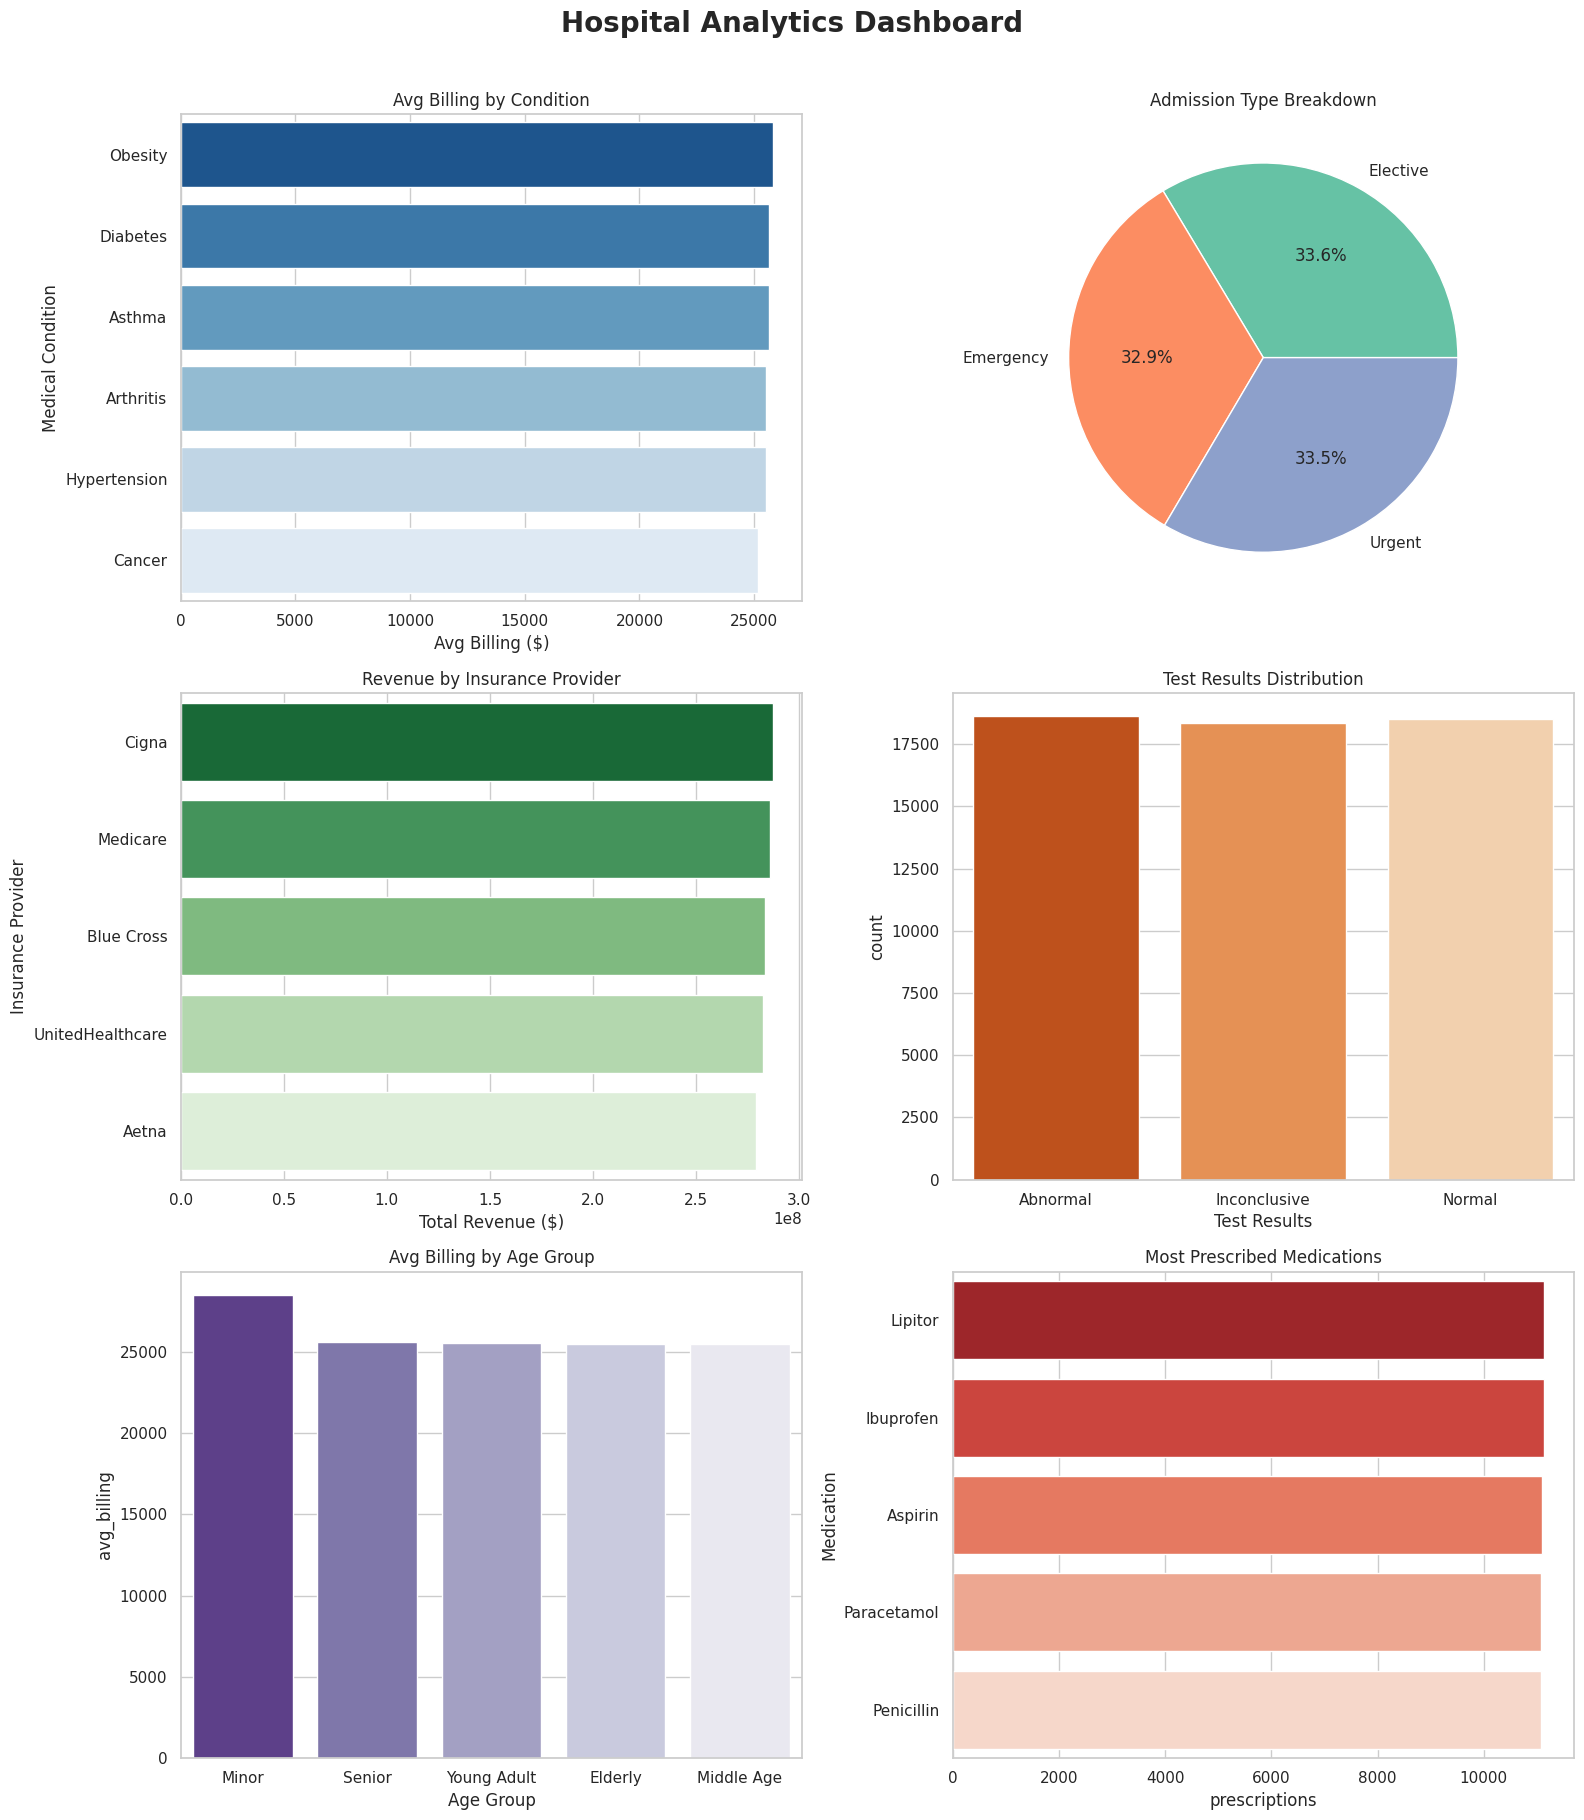

Dashboard saved!


In [4]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Hospital Analytics Dashboard', fontsize=20, fontweight='bold', y=1.01)

# 1. Avg Billing by Condition
df1 = pd.read_sql_query("""
    SELECT `Medical Condition`, ROUND(AVG(`Billing Amount`),2) AS avg_billing
    FROM healthcare GROUP BY `Medical Condition` ORDER BY avg_billing DESC
""", conn)
sns.barplot(data=df1, x='avg_billing', y='Medical Condition', ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('Avg Billing by Condition')
axes[0,0].set_xlabel('Avg Billing ($)')

# 2. Admission Type Pie
df2 = pd.read_sql_query("""
    SELECT `Admission Type`, COUNT(*) AS total FROM healthcare GROUP BY `Admission Type`
""", conn)
axes[0,1].pie(df2['total'], labels=df2['Admission Type'], autopct='%1.1f%%',
              colors=sns.color_palette('Set2'))
axes[0,1].set_title('Admission Type Breakdown')

# 3. Insurance Revenue
df3 = pd.read_sql_query("""
    SELECT `Insurance Provider`, ROUND(SUM(`Billing Amount`),2) AS total_revenue
    FROM healthcare GROUP BY `Insurance Provider` ORDER BY total_revenue DESC
""", conn)
sns.barplot(data=df3, x='total_revenue', y='Insurance Provider', ax=axes[1,0], palette='Greens_r')
axes[1,0].set_title('Revenue by Insurance Provider')
axes[1,0].set_xlabel('Total Revenue ($)')

# 4. Test Results Distribution
df4 = pd.read_sql_query("""
    SELECT `Test Results`, COUNT(*) AS count FROM healthcare GROUP BY `Test Results`
""", conn)
sns.barplot(data=df4, x='Test Results', y='count', ax=axes[1,1], palette='Oranges_r')
axes[1,1].set_title('Test Results Distribution')

# 5. Age Group Avg Billing
df5 = pd.read_sql_query("""
    SELECT CASE
        WHEN Age < 18 THEN 'Minor'
        WHEN Age BETWEEN 18 AND 35 THEN 'Young Adult'
        WHEN Age BETWEEN 36 AND 55 THEN 'Middle Age'
        WHEN Age BETWEEN 56 AND 70 THEN 'Senior'
        ELSE 'Elderly' END AS age_group,
        ROUND(AVG(`Billing Amount`),2) AS avg_billing
    FROM healthcare GROUP BY age_group ORDER BY avg_billing DESC
""", conn)
sns.barplot(data=df5, x='age_group', y='avg_billing', ax=axes[2,0], palette='Purples_r')
axes[2,0].set_title('Avg Billing by Age Group')
axes[2,0].set_xlabel('Age Group')

# 6. Top Medications
df6 = pd.read_sql_query("""
    SELECT Medication, COUNT(*) AS prescriptions
    FROM healthcare GROUP BY Medication ORDER BY prescriptions DESC
""", conn)
sns.barplot(data=df6, x='prescriptions', y='Medication', ax=axes[2,1], palette='Reds_r')
axes[2,1].set_title('Most Prescribed Medications')

plt.tight_layout()
plt.savefig('hospital_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")